In [40]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [41]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    KBinsDiscretizer
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report




In [42]:
df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
df_test = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')

In [43]:
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
9873,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
35909,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7146,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40693,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9892,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
df.shape

(42000, 785)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [46]:
df.duplicated().sum()

0

<Axes: xlabel='label'>

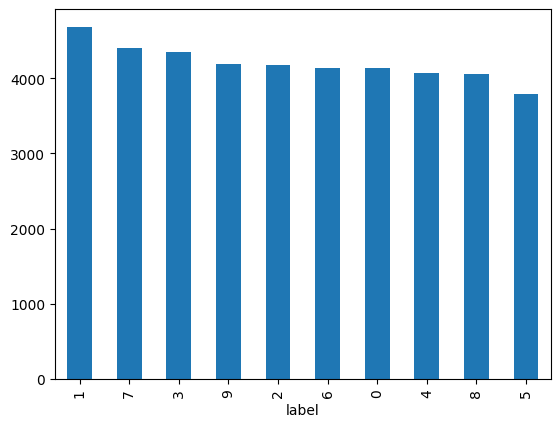

In [47]:
df["label"].value_counts().plot(kind="bar")

In [48]:
x = df.iloc[:,1:].values
y = df.iloc[:,:1]["label"]
x,y

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 0        1
 1        0
 2        1
 3        4
 4        0
         ..
 41995    0
 41996    1
 41997    7
 41998    6
 41999    9
 Name: label, Length: 42000, dtype: int64)

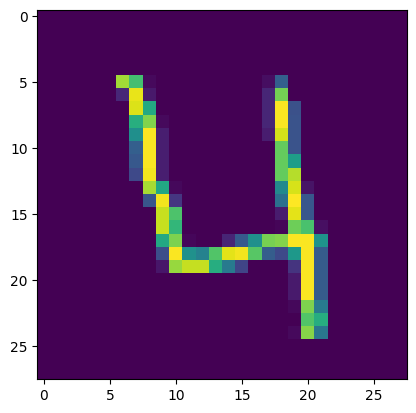

In [49]:
plt.imshow(x[3].reshape(28,28))

In [50]:
x_train,x_test , y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=20,stratify=y)

In [51]:
models = {
    # "logisticRegression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=200,max_depth=10, random_state=42),
    # "Gradient boosting": GradientBoostingClassifier(),
    # "SVM": SVC(probability=True)
}

In [52]:
result = {}

for name,clf in models.items():
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    score = accuracy_score(y_test, y_pred)

    result[name] = score

    print(f"{name}: {score}")
    print(classification_report(y_test, y_pred))
    print()

KNN: 0.9663492063492064
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1240
           1       0.95      0.99      0.97      1405
           2       0.98      0.94      0.96      1253
           3       0.96      0.96      0.96      1305
           4       0.98      0.96      0.97      1222
           5       0.95      0.96      0.96      1139
           6       0.97      0.99      0.98      1241
           7       0.95      0.97      0.96      1320
           8       0.99      0.91      0.95      1219
           9       0.96      0.96      0.96      1256

    accuracy                           0.97     12600
   macro avg       0.97      0.97      0.97     12600
weighted avg       0.97      0.97      0.97     12600


Decision Tree: 0.8425396825396826
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1240
           1       0.91      0.93      0.92      1405
           2       

In [ ]:
result_df = pd.DataFrame.from_dict(result,orient='index',columns=['Accuracy'])
result_df.sort_values(by='Accuracy',ascending=False)

,Accuracy
KNN,0.966349
Decision Tree,0.842540
Random Forest,0.947698
